# Milestone 1

1. **Synonymous Labels**
- Two or more values are syntactically different, but semantically similar (same activity, different names)
- Common when event log uses different original sources (different systems or people log the same action under different names) 
- difference to distorted labels?

2. **Collateral Events**
-  Multiple recorded events actually referring to the same conceptual event

3. **Scattered Cases**
- Key events are missing in the event log, since they are recorded elsewhere (One logical case split across multiple systems/tables)

4. **Unanchored events**: Problems with timedata

5. **Polluted labels**: Labels are structurally the same, yet are distinct from each other due to differences in the exact values => Remove mutable words, make immutable words the value of that attribute  

6. **Distorted labels**: Two or more values are very similar both syntactically and semantically (activity names that have been corrupted or misspelled)

In [91]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import pm4py
import random
import sys
from pathlib import Path

sys.path.append('../')
from modules.pollution_logic import *
from modules.remediation_logic import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Pollution Script

In [2]:
log = pm4py.read_xes("../data/BPI Challenge 2017.xes.gz")
df = pm4py.convert_to_dataframe(log)
df.head()

/home/thien/ProM-Assignment-Group-C/.venv/lib/python3.12/site-packages/pm4py/utils.py:1027: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(


parsing log, completed traces ::   0%|          | 0/31509 [00:00<?, ?it/s]

,Action,org:resource,concept:name,EventOrigin,EventID,lifecycle:transition,time:timestamp,case:LoanGoal,case:ApplicationType,case:concept:name,case:RequestedAmount,FirstWithdrawalAmount,NumberOfTerms,Accepted,MonthlyCost,Selected,CreditScore,OfferedAmount,OfferID
0,Created,User_1,A_Create Application,Application,Application_652823628,complete,2016-01-01 09:51:15.304000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,statechange,User_1,A_Submitted,Application,ApplState_1582051990,complete,2016-01-01 09:51:15.352000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Created,User_1,W_Handle leads,Workflow,Workitem_1298499574,schedule,2016-01-01 09:51:15.774000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Deleted,User_1,W_Handle leads,Workflow,Workitem_1673366067,withdraw,2016-01-01 09:52:36.392000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Created,User_1,W_Complete application,Workflow,Workitem_1493664571,schedule,2016-01-01 09:52:36.403000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1. Synonymous Labels

In [3]:
# Most common activities
df["concept:name"].value_counts().head(10)

concept:name
W_Validate application      209496
W_Call after offers         191092
W_Call incomplete files     168529
W_Complete application      148900
W_Handle leads               47264
O_Create Offer               42995
O_Created                    42995
O_Sent (mail and online)     39707
A_Validating                 38816
A_Create Application         31509
Name: count, dtype: int64

In [4]:
polluted_df_1 = add_synonymous_labels(df)
polluted_df_1["concept:name"].value_counts().head(20)

[synonymous_labels] Replaced 44670 / 148900 occurrences of 'W_Complete application'


concept:name
W_Validate application      209496
W_Call after offers         191092
W_Call incomplete files     168529
W_Complete application      104230
W_Handle leads               47264
O_Create Offer               42995
O_Created                    42995
O_Sent (mail and online)     39707
A_Validating                 38816
A_Create Application         31509
A_Concept                    31509
A_Accepted                   31509
A_Complete                   31362
O_Returned                   23305
A_Incomplete                 23055
O_Cancelled                  20898
A_Submitted                  20423
O_Accepted                   17228
A_Pending                    17228
W_Finish application         14900
Name: count, dtype: int64

### 2. Collateral Events

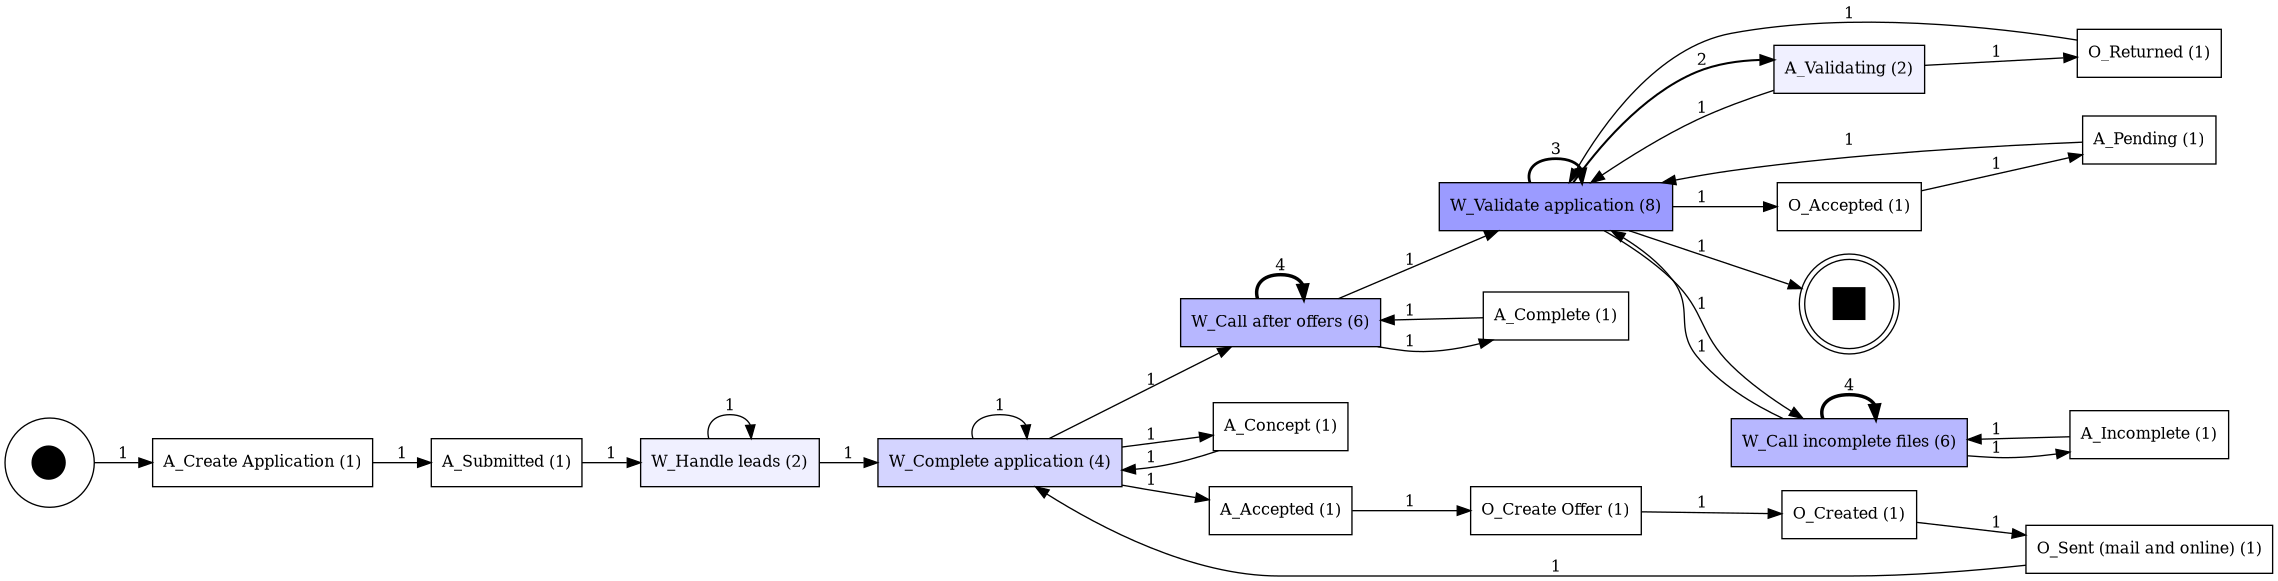

In [5]:
case_list = list(df['case:concept:name'].unique())
dfg, start_activities, end_activities = pm4py.discover_dfg(df[df['case:concept:name'].isin(case_list[:1])])
pm4py.view_dfg(dfg, start_activities, end_activities)

In [6]:
df[df['concept:name']=='W_Complete application'][['Action', 'concept:name', 'lifecycle:transition']].drop_duplicates()

,Action,concept:name,lifecycle:transition
4,Created,W_Complete application,schedule
6,Obtained,W_Complete application,start
7,Released,W_Complete application,suspend
12,Deleted,W_Complete application,ate_abort
48,Obtained,W_Complete application,resume
53,Deleted,W_Complete application,complete
461,Deleted,W_Complete application,withdraw


In [7]:
df['Action'].value_counts()

Action
statechange    358940
Obtained       255387
Created        223608
Released       215402
Deleted        148930
Name: count, dtype: int64

In [8]:
df['lifecycle:transition'].value_counts()

lifecycle:transition
complete     475306
suspend      215402
schedule     149104
start        128227
resume       127160
ate_abort     85224
withdraw      21844
Name: count, dtype: int64

In [9]:
polluted_df_2 = add_collateral_events(df)

In [10]:
target_cases = polluted_df_2[polluted_df_2["concept:name"] == "W_Precheck application: Applicant Identity"]["case:concept:name"].unique()
target_cases

<StringArray>
['Application_1008926043',   'Application_10744396', 'Application_1094857756',
   'Application_10985218',  'Application_114551747', 'Application_1371447312',
 'Application_1382416785', 'Application_1391286962', 'Application_1407908132',
 'Application_1503178371', 'Application_1557296300', 'Application_1566823764',
 'Application_1607234426', 'Application_1687844250', 'Application_1808348598',
 'Application_1904511216', 'Application_1957651168', 'Application_1962303803',
 'Application_1966741359', 'Application_2000400044', 'Application_2034443967',
 'Application_2120815918',  'Application_228285253',  'Application_246845710',
   'Application_42141968',  'Application_571266372',  'Application_674467574',
  'Application_828200680',  'Application_989064530']
Length: 29, dtype: str

In [13]:
test_raw = df[df["case:concept:name"]=='Application_1008926043'].sort_values(by=["case:concept:name", "time:timestamp"])
test_raw

,Action,org:resource,concept:name,EventOrigin,EventID,lifecycle:transition,time:timestamp,case:LoanGoal,case:ApplicationType,case:concept:name,case:RequestedAmount,FirstWithdrawalAmount,NumberOfTerms,Accepted,MonthlyCost,Selected,CreditScore,OfferedAmount,OfferID
640758,Created,User_21,A_Create Application,Application,Application_1008926043,complete,2016-07-22 07:48:15.478000+00:00,Unknown,New credit,Application_1008926043,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
640759,Created,User_21,W_Complete application,Workflow,Workitem_737821214,schedule,2016-07-22 07:48:15.498000+00:00,Unknown,New credit,Application_1008926043,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
640760,Obtained,User_21,W_Complete application,Workflow,Workitem_1742564688,start,2016-07-22 07:48:15.503000+00:00,Unknown,New credit,Application_1008926043,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
640761,statechange,User_21,A_Concept,Application,ApplState_1501511655,complete,2016-07-22 07:48:15.507000+00:00,Unknown,New credit,Application_1008926043,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
640762,statechange,User_21,A_Accepted,Application,ApplState_1486458543,complete,2016-07-22 07:52:39.207000+00:00,Unknown,New credit,Application_1008926043,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
640763,Created,User_21,O_Create Offer,Offer,Offer_38154362,complete,2016-07-22 08:00:13.942000+00:00,Unknown,New credit,Application_1008926043,0.0,3087.0,120.0,False,146.91,False,0.0,13800.0,NaN
640764,statechange,User_21,O_Created,Offer,OfferState_1997090880,complete,2016-07-22 08:00:14.630000+00:00,Unknown,New credit,Application_1008926043,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Offer_38154362
640765,Created,User_21,O_Create Offer,Offer,Offer_1474213077,complete,2016-07-22 08:01:40.482000+00:00,Unknown,New credit,Application_1008926043,0.0,4287.0,120.0,False,154.11,True,0.0,15000.0,NaN
640766,statechange,User_21,O_Created,Offer,OfferState_1807553910,complete,2016-07-22 08:01:41.556000+00:00,Unknown,New credit,Application_1008926043,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Offer_1474213077
640767,statechange,User_21,O_Sent (mail and online),Offer,OfferState_1247358786,complete,2016-07-22 08:02:03.052000+00:00,Unknown,New credit,Application_1008926043,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Offer_1474213077


In [14]:
test_polluted =polluted_df_2[polluted_df_2["case:concept:name"]=='Application_1008926043'].sort_values(by=["case:concept:name", "time:timestamp"])
test_polluted

,Action,org:resource,concept:name,EventOrigin,EventID,lifecycle:transition,time:timestamp,case:LoanGoal,case:ApplicationType,case:concept:name,case:RequestedAmount,FirstWithdrawalAmount,NumberOfTerms,Accepted,MonthlyCost,Selected,CreditScore,OfferedAmount,OfferID,start_timestamp
5455,Created,User_21,A_Create Application,Application,Application_1008926043,complete,2016-07-22 07:48:15.478000+00:00,Unknown,New credit,Application_1008926043,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
5456,Created,User_21,W_Complete application,Workflow,Workitem_737821214,schedule,2016-07-22 07:48:15.498000+00:00,Unknown,New credit,Application_1008926043,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
5457,Obtained,User_21,W_Complete application,Workflow,Workitem_1742564688,start,2016-07-22 07:48:15.503000+00:00,Unknown,New credit,Application_1008926043,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
5458,statechange,User_21,A_Concept,Application,ApplState_1501511655,complete,2016-07-22 07:48:15.507000+00:00,Unknown,New credit,Application_1008926043,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
5459,Obtained,User_21,W_Precheck application: Applicant Identity,Workflow,Workitem_1742564688,start,2016-07-22 07:48:16.503000+00:00,Unknown,New credit,Application_1008926043,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-07-22 07:48:16.503000+00:00
5460,Obtained,User_21,W_Precheck application: Form Completeness,Workflow,Workitem_1742564688,start,2016-07-22 07:48:17.503000+00:00,Unknown,New credit,Application_1008926043,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-07-22 07:48:17.503000+00:00
5461,Obtained,User_21,W_Precheck application: Credit History,Workflow,Workitem_1742564688,start,2016-07-22 07:48:18.503000+00:00,Unknown,New credit,Application_1008926043,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-07-22 07:48:18.503000+00:00
5462,statechange,User_21,A_Accepted,Application,ApplState_1486458543,complete,2016-07-22 07:52:39.207000+00:00,Unknown,New credit,Application_1008926043,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
5463,Created,User_21,O_Create Offer,Offer,Offer_38154362,complete,2016-07-22 08:00:13.942000+00:00,Unknown,New credit,Application_1008926043,0.0,3087.0,120.0,False,146.91,False,0.0,13800.0,NaN,NaT
5464,statechange,User_21,O_Created,Offer,OfferState_1997090880,complete,2016-07-22 08:00:14.630000+00:00,Unknown,New credit,Application_1008926043,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Offer_38154362,NaT


### 3. Scattered Cases

In [15]:
df[df['concept:name'].str.contains("valid", case=False)]['concept:name'].value_counts()

concept:name
W_Validate application    209496
A_Validating               38816
Name: count, dtype: int64

In [16]:
polluted_df_3 = add_scattered_cases(
    df, 
    output_path="../data/polluted_data/scattered_events_validation.csv",
    concept_name="valid"
)

Saved removed events to: ../data/polluted_data/scattered_events_validation.csv


### Combination of 3 patterns

In [31]:
polluted_df = add_synonymous_labels(df)
polluted_df = add_collateral_events(polluted_df)
polluted_df = add_scattered_cases(
    polluted_df, 
    output_path="../data/polluted_data/scattered_events_validation.csv",
    concept_name="valid"
)

[synonymous_labels] Replaced 44670 / 148900 occurrences of 'W_Complete application'
Saved removed events to: ../data/polluted_data/scattered_events_validation.csv


In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1202267 entries, 0 to 1202266
Data columns (total 19 columns):
 #   Column                 Non-Null Count    Dtype              
---  ------                 --------------    -----              
 0   Action                 1202267 non-null  str                
 1   org:resource           1202267 non-null  str                
 2   concept:name           1202267 non-null  str                
 3   EventOrigin            1202267 non-null  str                
 4   EventID                1202267 non-null  str                
 5   lifecycle:transition   1202267 non-null  str                
 6   time:timestamp         1202267 non-null  datetime64[us, UTC]
 7   case:LoanGoal          1202267 non-null  str                
 8   case:ApplicationType   1202267 non-null  str                
 9   case:concept:name      1202267 non-null  str                
 10  case:RequestedAmount   1202267 non-null  float64            
 11  FirstWithdrawalAmount  42995 non-nu

In [34]:
polluted_df.info()

<class 'pandas.DataFrame'>
Index: 954015 entries, 0 to 1202326
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype              
---  ------                 --------------   -----              
 0   Action                 954015 non-null  str                
 1   org:resource           954015 non-null  str                
 2   concept:name           954015 non-null  str                
 3   EventOrigin            954015 non-null  str                
 4   EventID                954015 non-null  str                
 5   lifecycle:transition   954015 non-null  str                
 6   time:timestamp         954015 non-null  datetime64[us, UTC]
 7   case:LoanGoal          954015 non-null  str                
 8   case:ApplicationType   954015 non-null  str                
 9   case:concept:name      954015 non-null  str                
 10  case:RequestedAmount   954015 non-null  float64            
 11  FirstWithdrawalAmount  42995 non-null   float64       

In [35]:
polluted_log = pm4py.convert_to_event_log(polluted_df)
pm4py.write_xes(polluted_log, "../data/polluted_data/polluted_log.xes")

exporting log, completed traces ::   0%|          | 0/31509 [00:00<?, ?it/s]

In [22]:
polluted_log = pm4py.read_xes("../data/polluted_data/polluted_log.xes")
polluted_df = pm4py.convert_to_dataframe(polluted_log)
polluted_df.info()

parsing log, completed traces ::   0%|          | 0/31509 [00:00<?, ?it/s]

<class 'pandas.DataFrame'>
RangeIndex: 954015 entries, 0 to 954014
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype              
---  ------                 --------------   -----              
 0   Action                 954015 non-null  str                
 1   org:resource           954015 non-null  str                
 2   concept:name           954015 non-null  str                
 3   EventOrigin            954015 non-null  str                
 4   EventID                954015 non-null  str                
 5   lifecycle:transition   954015 non-null  str                
 6   time:timestamp         954015 non-null  datetime64[us, UTC]
 7   FirstWithdrawalAmount  42995 non-null   float64            
 8   NumberOfTerms          42995 non-null   float64            
 9   Accepted               42995 non-null   object             
 10  MonthlyCost            42995 non-null   float64            
 11  Selected               42995 non-null   object    

In [23]:
polluted_df.head()

,Action,org:resource,concept:name,EventOrigin,EventID,lifecycle:transition,time:timestamp,FirstWithdrawalAmount,NumberOfTerms,Accepted,MonthlyCost,Selected,CreditScore,OfferedAmount,OfferID,start_timestamp,case:LoanGoal,case:ApplicationType,case:concept:name,case:RequestedAmount
0,Created,User_1,A_Create Application,Application,Application_1000086665,complete,2016-08-03 15:57:21.673000+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,"Other, see explanation",New credit,Application_1000086665,5000.0
1,statechange,User_1,A_Submitted,Application,ApplState_161925113,complete,2016-08-03 15:57:21.734000+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,"Other, see explanation",New credit,Application_1000086665,5000.0
2,Created,User_1,W_Handle leads,Workflow,Workitem_747707399,schedule,2016-08-03 15:57:21.963000+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,"Other, see explanation",New credit,Application_1000086665,5000.0
3,Deleted,User_1,W_Handle leads,Workflow,Workitem_1030261128,withdraw,2016-08-03 15:58:28.286000+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,"Other, see explanation",New credit,Application_1000086665,5000.0
4,Created,User_1,W_Complete application,Workflow,Workitem_1127124826,schedule,2016-08-03 15:58:28.293000+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,"Other, see explanation",New credit,Application_1000086665,5000.0


In [24]:
polluted_df[polluted_df["concept:name"]=="W_Precheck application: Applicant Identity"]

,Action,org:resource,concept:name,EventOrigin,EventID,lifecycle:transition,time:timestamp,FirstWithdrawalAmount,NumberOfTerms,Accepted,MonthlyCost,Selected,CreditScore,OfferedAmount,OfferID,start_timestamp,case:LoanGoal,case:ApplicationType,case:concept:name,case:RequestedAmount
37915,Obtained,User_37,W_Precheck application: Applicant Identity,Workflow,Workitem_262659018,start,2016-03-09 13:02:15.368000+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-03-09 13:02:15.368000+00:00,Extra spending limit,New credit,Application_1078949552,5000.0
116557,Obtained,User_40,W_Precheck application: Applicant Identity,Workflow,Workitem_930134289,start,2016-07-05 10:13:11.342000+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-07-05 10:13:11.342000+00:00,Existing loan takeover,New credit,Application_1236023092,18000.0
168671,Obtained,User_56,W_Precheck application: Applicant Identity,Workflow,Workitem_787459536,start,2016-08-22 18:39:17.969000+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-08-22 18:39:17.969000+00:00,Car,New credit,Application_1336110675,11300.0
170366,Obtained,User_38,W_Precheck application: Applicant Identity,Workflow,Workitem_1200676741,start,2016-03-08 09:44:51.298000+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-03-08 09:44:51.298000+00:00,"Other, see explanation",New credit,Application_1340675211,20000.0
178090,Obtained,User_15,W_Precheck application: Applicant Identity,Workflow,Workitem_1079592166,start,2016-08-18 13:00:53.001000+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-08-18 13:00:53.001000+00:00,Home improvement,New credit,Application_1358901285,20000.0
195779,Obtained,User_3,W_Precheck application: Applicant Identity,Workflow,Workitem_1911248133,start,2016-09-23 09:59:03.248000+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-09-23 09:59:03.248000+00:00,Car,New credit,Application_1392194089,5000.0
255071,Obtained,User_67,W_Precheck application: Applicant Identity,Workflow,Workitem_1282148968,start,2016-09-27 14:13:45.540000+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-09-27 14:13:45.540000+00:00,Existing loan takeover,New credit,Application_1507233481,15000.0
257618,Obtained,User_28,W_Precheck application: Applicant Identity,Workflow,Workitem_341424269,start,2016-08-22 06:43:30.235000+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-08-22 06:43:30.235000+00:00,Existing loan takeover,New credit,Application_1512468457,50000.0
382339,Obtained,User_77,W_Precheck application: Applicant Identity,Workflow,Workitem_987105460,start,2016-10-31 15:24:31.893000+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-10-31 15:24:31.893000+00:00,Unknown,New credit,Application_1768718354,0.0
390138,Obtained,User_51,W_Precheck application: Applicant Identity,Workflow,Workitem_2018587301,start,2016-04-26 15:56:16.861000+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-04-26 15:56:16.861000+00:00,Car,New credit,Application_1782970759,20000.0


## Remediation script

In [ ]:
polluted_log = pm4py.read_xes("../data/polluted_data/polluted_log.xes")
polluted_df = pm4py.convert_to_dataframe(polluted_log)
polluted_df.info()

### 1. Synonymous Labels

In [38]:
result = find_similar_labels(polluted_df, threshold=0.65, prefix_filter = True)
result

,label_1,label_2,similarity
0,W_Complete application,W_Finalize application,0.667781
1,W_Finish application,W_Finalize application,0.746601
2,O_Sent (mail and online),O_Sent (online only),0.902949
3,W_Precheck application: Applicant Identity,W_Precheck application: Form Completeness,0.708304
4,W_Precheck application: Applicant Identity,W_Precheck application: Credit History,0.712661
5,W_Precheck application: Form Completeness,W_Precheck application: Credit History,0.663201


In [39]:
SYNONYMOUS_LABELS = ["W_Complete application", "W_Finish application", "W_Finalize application"]
polluted_df[polluted_df["concept:name"].isin(SYNONYMOUS_LABELS)]["concept:name"].value_counts()

concept:name
W_Complete application    104230
W_Finalize application     22367
W_Finish application       22303
Name: count, dtype: int64

In [40]:
cleaned_df = replace_with_most_frequent(polluted_df, SYNONYMOUS_LABELS)
cleaned_df[cleaned_df["concept:name"].isin(SYNONYMOUS_LABELS)]["concept:name"].value_counts()

concept:name
W_Complete application    148900
Name: count, dtype: int64

### 2. Collateral events

In [51]:
result_for_collateral = result[~result['label_1'].isin(SYNONYMOUS_LABELS)]
detect_collateral_events = detect_collateral_events(polluted_df, time_window="5s", similarity=True, similarity_df=result_for_collateral, threshold=0.65)

In [52]:
set(detect_collateral_events['event_1'].unique()) | set(detect_collateral_events['event_2'].unique())

{'W_Precheck application: Applicant Identity',
 'W_Precheck application: Credit History',
 'W_Precheck application: Form Completeness'}

In [92]:
COLLATERAL_LABELS_DICT = {
  "W_Precheck application": [
    "W_Precheck application: Applicant Identity",
    "W_Precheck application: Form Completeness",
    "W_Precheck application: Credit History"
  ]
}
cleaned_df = merge_collateral_events(polluted_df, COLLATERAL_LABELS_DICT)

Rows to drop: 60
Rows added: 20


In [93]:
cleaned_df[cleaned_df["case:concept:name"]=='Application_1132453497']

,Action,org:resource,concept:name,EventOrigin,EventID,lifecycle:transition,time:timestamp,case:LoanGoal,case:ApplicationType,case:concept:name,case:RequestedAmount,FirstWithdrawalAmount,NumberOfTerms,Accepted,MonthlyCost,Selected,CreditScore,OfferedAmount,OfferID,start_timestamp
65332,Created,User_17,A_Create Application,Application,Application_1132453497,complete,2016-10-14 11:10:47.171000+00:00,Unknown,New credit,Application_1132453497,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
65333,Created,User_17,W_Finalize application,Workflow,Workitem_1783362211,schedule,2016-10-14 11:10:47.183000+00:00,Unknown,New credit,Application_1132453497,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
65334,Obtained,User_17,W_Complete application,Workflow,Workitem_1245650304,start,2016-10-14 11:10:47.186000+00:00,Unknown,New credit,Application_1132453497,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
65335,statechange,User_17,A_Concept,Application,ApplState_1588276522,complete,2016-10-14 11:10:47.189000+00:00,Unknown,New credit,Application_1132453497,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
65336,Obtained,User_17,W_Precheck application,Workflow,Workitem_1245650304,start,2016-10-14 11:10:48.186000+00:00,Unknown,New credit,Application_1132453497,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-10-14 11:10:48.186000+00:00
65337,statechange,User_17,A_Accepted,Application,ApplState_2023502931,complete,2016-10-14 11:13:26.883000+00:00,Unknown,New credit,Application_1132453497,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
65338,Created,User_17,O_Create Offer,Offer,Offer_1304487534,complete,2016-10-14 11:20:42.574000+00:00,Unknown,New credit,Application_1132453497,0.0,0.0,61.0,True,325.49,True,882.0,17800.0,NaN,NaT
65339,statechange,User_17,O_Created,Offer,OfferState_896369551,complete,2016-10-14 11:20:43.111000+00:00,Unknown,New credit,Application_1132453497,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Offer_1304487534,NaT
65340,statechange,User_17,O_Sent (online only),Offer,OfferState_1852627843,complete,2016-10-14 11:20:50.800000+00:00,Unknown,New credit,Application_1132453497,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Offer_1304487534,NaT
65341,Deleted,User_17,W_Complete application,Workflow,Workitem_915491744,complete,2016-10-14 11:20:50.813000+00:00,Unknown,New credit,Application_1132453497,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT


In [94]:
polluted_df[polluted_df["case:concept:name"]=='Application_1132453497']

,Action,org:resource,concept:name,EventOrigin,EventID,lifecycle:transition,time:timestamp,case:LoanGoal,case:ApplicationType,case:concept:name,case:RequestedAmount,FirstWithdrawalAmount,NumberOfTerms,Accepted,MonthlyCost,Selected,CreditScore,OfferedAmount,OfferID,start_timestamp
82641,Created,User_17,A_Create Application,Application,Application_1132453497,complete,2016-10-14 11:10:47.171000+00:00,Unknown,New credit,Application_1132453497,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
82642,Created,User_17,W_Finalize application,Workflow,Workitem_1783362211,schedule,2016-10-14 11:10:47.183000+00:00,Unknown,New credit,Application_1132453497,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
82643,Obtained,User_17,W_Complete application,Workflow,Workitem_1245650304,start,2016-10-14 11:10:47.186000+00:00,Unknown,New credit,Application_1132453497,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
82644,statechange,User_17,A_Concept,Application,ApplState_1588276522,complete,2016-10-14 11:10:47.189000+00:00,Unknown,New credit,Application_1132453497,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
82645,Obtained,User_17,W_Precheck application: Applicant Identity,Workflow,Workitem_1245650304,start,2016-10-14 11:10:48.186000+00:00,Unknown,New credit,Application_1132453497,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-10-14 11:10:48.186000+00:00
82646,Obtained,User_17,W_Precheck application: Form Completeness,Workflow,Workitem_1245650304,start,2016-10-14 11:10:49.186000+00:00,Unknown,New credit,Application_1132453497,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-10-14 11:10:49.186000+00:00
82647,Obtained,User_17,W_Precheck application: Credit History,Workflow,Workitem_1245650304,start,2016-10-14 11:10:50.186000+00:00,Unknown,New credit,Application_1132453497,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-10-14 11:10:50.186000+00:00
82648,statechange,User_17,A_Accepted,Application,ApplState_2023502931,complete,2016-10-14 11:13:26.883000+00:00,Unknown,New credit,Application_1132453497,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
82649,Created,User_17,O_Create Offer,Offer,Offer_1304487534,complete,2016-10-14 11:20:42.574000+00:00,Unknown,New credit,Application_1132453497,0.0,0.0,61.0,True,325.49,True,882.0,17800.0,NaN,NaT
82650,statechange,User_17,O_Created,Offer,OfferState_896369551,complete,2016-10-14 11:20:43.111000+00:00,Unknown,New credit,Application_1132453497,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Offer_1304487534,NaT


### Combination of 3 patterns

In [95]:
cleaned_df = replace_with_most_frequent(polluted_df, SYNONYMOUS_LABELS)
cleaned_df = merge_collateral_events(cleaned_df, COLLATERAL_LABELS_DICT)

Rows to drop: 60
Rows added: 20


In [ ]:
cleaned_log = pm4py.convert_to_event_log(cleaned_df)
output_dir = Path("../data/cleaned_data")
output_dir.mkdir(parents=True, exist_ok=True)
pm4py.write_xes(cleaned_log, "../data/cleaned_data/cleaned_log.xes")

exporting log, completed traces ::   0%|          | 0/31509 [00:00<?, ?it/s]